# Data Transformation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#Loading data and viewing data

flight_clean = pd.read_csv("final_database_Comp333.csv")
flight_clean.head()

,FL_DATE,CARRIER_CODE,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,CRS_ARR_TIME,ARR_TIME,DEP_DELAY,ARR_DELAY,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,CANCELLED,TOTAL_DELAY
0,1/2/2023 12:00:00 AM,9E,BDL,LGA,800,757.0,905,853.0,-3.0,-12.0,0.0,0.0,0.0,0.0,0.0,0.0,-15.0
1,1/2/2023 12:00:00 AM,9E,DLH,MSP,510,502.0,626,622.0,-8.0,-4.0,0.0,0.0,0.0,0.0,0.0,0.0,-12.0
2,1/2/2023 12:00:00 AM,9E,ORF,DTW,530,526.0,735,728.0,-4.0,-7.0,0.0,0.0,0.0,0.0,0.0,0.0,-11.0
3,1/2/2023 12:00:00 AM,9E,MSP,PIT,910,911.0,1220,1219.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1/2/2023 12:00:00 AM,9E,PIT,MSP,1310,1305.0,1440,1446.0,-5.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [3]:
flight_clean.shape

(6847899, 17)

In [4]:


total = flight_clean.isnull().sum().sort_values(ascending=False)
percent = (flight_clean.isnull().sum()/len(flight_clean)).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data

,Total,Percent
ARR_TIME,89622,0.013088
DEP_TIME,84469,0.012335
FL_DATE,0,0.000000
CARRIER_CODE,0,0.000000
ORIGIN,0,0.000000
CRS_DEP_TIME,0,0.000000
DEST,0,0.000000
CRS_ARR_TIME,0,0.000000
DEP_DELAY,0,0.000000
ARR_DELAY,0,0.000000


In [5]:

# 1) Drop rows where DEP_TIME or ARR_TIME is missing
flight_clean = flight_clean.dropna(subset=['DEP_TIME', 'ARR_TIME'])

In [6]:
flight_clean.isnull().sum().sort_values(ascending=False)

,0
FL_DATE,0
CARRIER_CODE,0
ORIGIN,0
DEST,0
CRS_DEP_TIME,0
DEP_TIME,0
CRS_ARR_TIME,0
ARR_TIME,0
DEP_DELAY,0
ARR_DELAY,0


In [7]:
flight_clean_copy = flight_clean.copy()

In [8]:
flight_clean.loc[:, 'FL_DATE'] = pd.to_datetime(flight_clean['FL_DATE'], format='%m/%d/%Y %I:%M:%S %p')

In [9]:
flight_clean.head()

,FL_DATE,CARRIER_CODE,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,CRS_ARR_TIME,ARR_TIME,DEP_DELAY,ARR_DELAY,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,CANCELLED,TOTAL_DELAY
0,2023-01-02 00:00:00,9E,BDL,LGA,800,757.0,905,853.0,-3.0,-12.0,0.0,0.0,0.0,0.0,0.0,0.0,-15.0
1,2023-01-02 00:00:00,9E,DLH,MSP,510,502.0,626,622.0,-8.0,-4.0,0.0,0.0,0.0,0.0,0.0,0.0,-12.0
2,2023-01-02 00:00:00,9E,ORF,DTW,530,526.0,735,728.0,-4.0,-7.0,0.0,0.0,0.0,0.0,0.0,0.0,-11.0
3,2023-01-02 00:00:00,9E,MSP,PIT,910,911.0,1220,1219.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2023-01-02 00:00:00,9E,PIT,MSP,1310,1305.0,1440,1446.0,-5.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [10]:
flight_clean_copy2 = flight_clean.copy()

In [11]:
flight_clean['FL_DATE'] = pd.to_datetime(flight_clean['FL_DATE'], format='%m/%d/%Y %I:%M:%S %p')


In [12]:
# Extract the month, year, and day of week
flight_clean['MONTH'] = flight_clean['FL_DATE'].dt.month
flight_clean['YEAR'] = flight_clean['FL_DATE'].dt.year
flight_clean['DAY_OF_WEEK'] = flight_clean['FL_DATE'].dt.dayofweek  # Monday=0, Sunday=6

In [13]:
flight_clean.head()

,FL_DATE,CARRIER_CODE,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,CRS_ARR_TIME,ARR_TIME,DEP_DELAY,ARR_DELAY,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,CANCELLED,TOTAL_DELAY,MONTH,YEAR,DAY_OF_WEEK
0,2023-01-02,9E,BDL,LGA,800,757.0,905,853.0,-3.0,-12.0,0.0,0.0,0.0,0.0,0.0,0.0,-15.0,1,2023,0
1,2023-01-02,9E,DLH,MSP,510,502.0,626,622.0,-8.0,-4.0,0.0,0.0,0.0,0.0,0.0,0.0,-12.0,1,2023,0
2,2023-01-02,9E,ORF,DTW,530,526.0,735,728.0,-4.0,-7.0,0.0,0.0,0.0,0.0,0.0,0.0,-11.0,1,2023,0
3,2023-01-02,9E,MSP,PIT,910,911.0,1220,1219.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2023,0
4,2023-01-02,9E,PIT,MSP,1310,1305.0,1440,1446.0,-5.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,2023,0


In [14]:
# Method 3: Inplace modification (modifies directly, no reassignment needed)
flight_clean.drop('FL_DATE', axis=1, inplace=True)

In [15]:
flight_clean.head()

,CARRIER_CODE,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,CRS_ARR_TIME,ARR_TIME,DEP_DELAY,ARR_DELAY,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,CANCELLED,TOTAL_DELAY,MONTH,YEAR,DAY_OF_WEEK
0,9E,BDL,LGA,800,757.0,905,853.0,-3.0,-12.0,0.0,0.0,0.0,0.0,0.0,0.0,-15.0,1,2023,0
1,9E,DLH,MSP,510,502.0,626,622.0,-8.0,-4.0,0.0,0.0,0.0,0.0,0.0,0.0,-12.0,1,2023,0
2,9E,ORF,DTW,530,526.0,735,728.0,-4.0,-7.0,0.0,0.0,0.0,0.0,0.0,0.0,-11.0,1,2023,0
3,9E,MSP,PIT,910,911.0,1220,1219.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2023,0
4,9E,PIT,MSP,1310,1305.0,1440,1446.0,-5.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,2023,0


In [16]:
flight_clean.drop('YEAR', axis=1, inplace=True)

In [17]:
flight_clean.head()

,CARRIER_CODE,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,CRS_ARR_TIME,ARR_TIME,DEP_DELAY,ARR_DELAY,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,CANCELLED,TOTAL_DELAY,MONTH,DAY_OF_WEEK
0,9E,BDL,LGA,800,757.0,905,853.0,-3.0,-12.0,0.0,0.0,0.0,0.0,0.0,0.0,-15.0,1,0
1,9E,DLH,MSP,510,502.0,626,622.0,-8.0,-4.0,0.0,0.0,0.0,0.0,0.0,0.0,-12.0,1,0
2,9E,ORF,DTW,530,526.0,735,728.0,-4.0,-7.0,0.0,0.0,0.0,0.0,0.0,0.0,-11.0,1,0
3,9E,MSP,PIT,910,911.0,1220,1219.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
4,9E,PIT,MSP,1310,1305.0,1440,1446.0,-5.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0


In [18]:

# Creating a binary target variable
flight_clean['delayed'] = (flight_clean['TOTAL_DELAY'] > 15).astype(int)
#vefirifying if data is balanced
flight_clean['delayed'].value_counts(normalize=True)

,proportion
delayed,
0,0.736024
1,0.263976


In [19]:
flight_clean.head()

,CARRIER_CODE,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,CRS_ARR_TIME,ARR_TIME,DEP_DELAY,ARR_DELAY,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,CANCELLED,TOTAL_DELAY,MONTH,DAY_OF_WEEK,delayed
0,9E,BDL,LGA,800,757.0,905,853.0,-3.0,-12.0,0.0,0.0,0.0,0.0,0.0,0.0,-15.0,1,0,0
1,9E,DLH,MSP,510,502.0,626,622.0,-8.0,-4.0,0.0,0.0,0.0,0.0,0.0,0.0,-12.0,1,0,0
2,9E,ORF,DTW,530,526.0,735,728.0,-4.0,-7.0,0.0,0.0,0.0,0.0,0.0,0.0,-11.0,1,0,0
3,9E,MSP,PIT,910,911.0,1220,1219.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0
4,9E,PIT,MSP,1310,1305.0,1440,1446.0,-5.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0,0


In [3]:
#spliting data in train and test 80 -20

from sklearn.model_selection import train_test_split

X = flight_clean[['CARRIER_CODE', 'ORIGIN', 'DEST','CRS_DEP_TIME', 'DEP_TIME', 'CRS_ARR_TIME', 'ARR_TIME', 'DEP_DELAY', 'ARR_DELAY', 'CARRIER_DELAY', 'WEATHER_DELAY',
                                'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'CANCELLED',
                                'MONTH', 'DAY_OF_WEEK']]  # features
y = flight_clean['delayed']   # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

len(X_train), len(X_test)


(5406621, 1351656)

In [4]:
X_train.head()

,CARRIER_CODE,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,CRS_ARR_TIME,ARR_TIME,DEP_DELAY,ARR_DELAY,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,CANCELLED,MONTH,DAY_OF_WEEK
4747709,UA,SFO,RDM,1035,1035.0,1215,1211.0,0.0,-4.0,0.0,0.0,0.0,0.0,0.0,0.0,9,3
1407817,OO,ICT,DEN,1201,1207.0,1245,1244.0,6.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,3,4
2023770,AS,PSP,PDX,1745,1736.0,2011,2006.0,-9.0,-5.0,0.0,0.0,0.0,0.0,0.0,0.0,4,5
5032097,AA,CLT,JFK,2029,2023.0,2225,2218.0,-6.0,-7.0,0.0,0.0,0.0,0.0,0.0,0.0,10,0
6710181,AA,SBA,DFW,600,557.0,1113,1110.0,-3.0,-3.0,0.0,0.0,0.0,0.0,0.0,0.0,12,6


In [14]:
y_train.head(),y_test.head()

(4747709    0
 1407817    0
 2023770    0
 5032097    0
 6710181    0
 Name: delayed, dtype: int64,
 239413     0
 6381773    0
 1527931    1
 5919884    0
 6377560    0
 Name: delayed, dtype: int64)

In [4]:
from sklearn.preprocessing import OrdinalEncoder
cat_cols = ['CARRIER_CODE', 'ORIGIN', 'DEST']
num_cols = ['CRS_DEP_TIME', 'DEP_TIME', 'CRS_ARR_TIME', 'ARR_TIME', 'DEP_DELAY', 'ARR_DELAY', 'CARRIER_DELAY', 'WEATHER_DELAY',
            'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'CANCELLED', 'MONTH', 'DAY_OF_WEEK']
X_train = X_train.copy()
X_test = X_test.copy()

# OrdinalEncoder handles unknown values automatically
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

In [19]:
X_test.head()

,CARRIER_CODE,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,CRS_ARR_TIME,ARR_TIME,DEP_DELAY,ARR_DELAY,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,CANCELLED,MONTH,DAY_OF_WEEK
239413,-1.0,-1.0,-1.0,815,811.0,930,933.0,-4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1,3
6381773,-1.0,-1.0,-1.0,1005,1003.0,1204,1141.0,-2.0,-23.0,0.0,0.0,0.0,0.0,0.0,0.0,12,2
1527931,-1.0,-1.0,-1.0,930,940.0,1125,1143.0,10.0,18.0,0.0,0.0,18.0,0.0,0.0,0.0,3,6
5919884,-1.0,-1.0,-1.0,1130,1135.0,1730,1729.0,5.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,11,3
6377560,-1.0,-1.0,-1.0,1710,1706.0,2035,1951.0,-4.0,-44.0,0.0,0.0,0.0,0.0,0.0,0.0,12,2


In [5]:
X_test.drop('CANCELLED', axis=1, inplace=True)

In [6]:
X_train.drop('CANCELLED', axis=1, inplace=True)

In [7]:
# Drop columns based on correlation analysis
flight_clean_check = flight_clean.drop(columns=[
    'CARRIER_CODE',   # Low correlation with target (total_delay)
          # Weak correlation with target
    'CANCELLED', 'ORIGIN', 'DEST'   # Weak correlation with target
])

# Check the columns after dropping
print(flight_clean.columns)


Index(['CARRIER_CODE', 'ORIGIN', 'DEST', 'CRS_DEP_TIME', 'DEP_TIME',
       'CRS_ARR_TIME', 'ARR_TIME', 'DEP_DELAY', 'ARR_DELAY', 'CARRIER_DELAY',
       'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY',
       'CANCELLED', 'TOTAL_DELAY', 'MONTH', 'DAY_OF_WEEK', 'delayed'],
      dtype='object')


In [34]:
flight_clean_check .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6758277 entries, 0 to 6758276
Data columns (total 18 columns):
 #   Column               Dtype  
---  ------               -----  
 0   CARRIER_CODE         object 
 1   ORIGIN               object 
 2   DEST                 object 
 3   CRS_DEP_TIME         int64  
 4   DEP_TIME             float64
 5   CRS_ARR_TIME         int64  
 6   ARR_TIME             float64
 7   DEP_DELAY            float64
 8   ARR_DELAY            float64
 9   CARRIER_DELAY        float64
 10  WEATHER_DELAY        float64
 11  NAS_DELAY            float64
 12  SECURITY_DELAY       float64
 13  LATE_AIRCRAFT_DELAY  float64
 14  TOTAL_DELAY          float64
 15  MONTH                int64  
 16  DAY_OF_WEEK          int64  
 17  delayed              int64  
dtypes: float64(10), int64(5), object(3)
memory usage: 928.1+ MB


<Axes: >

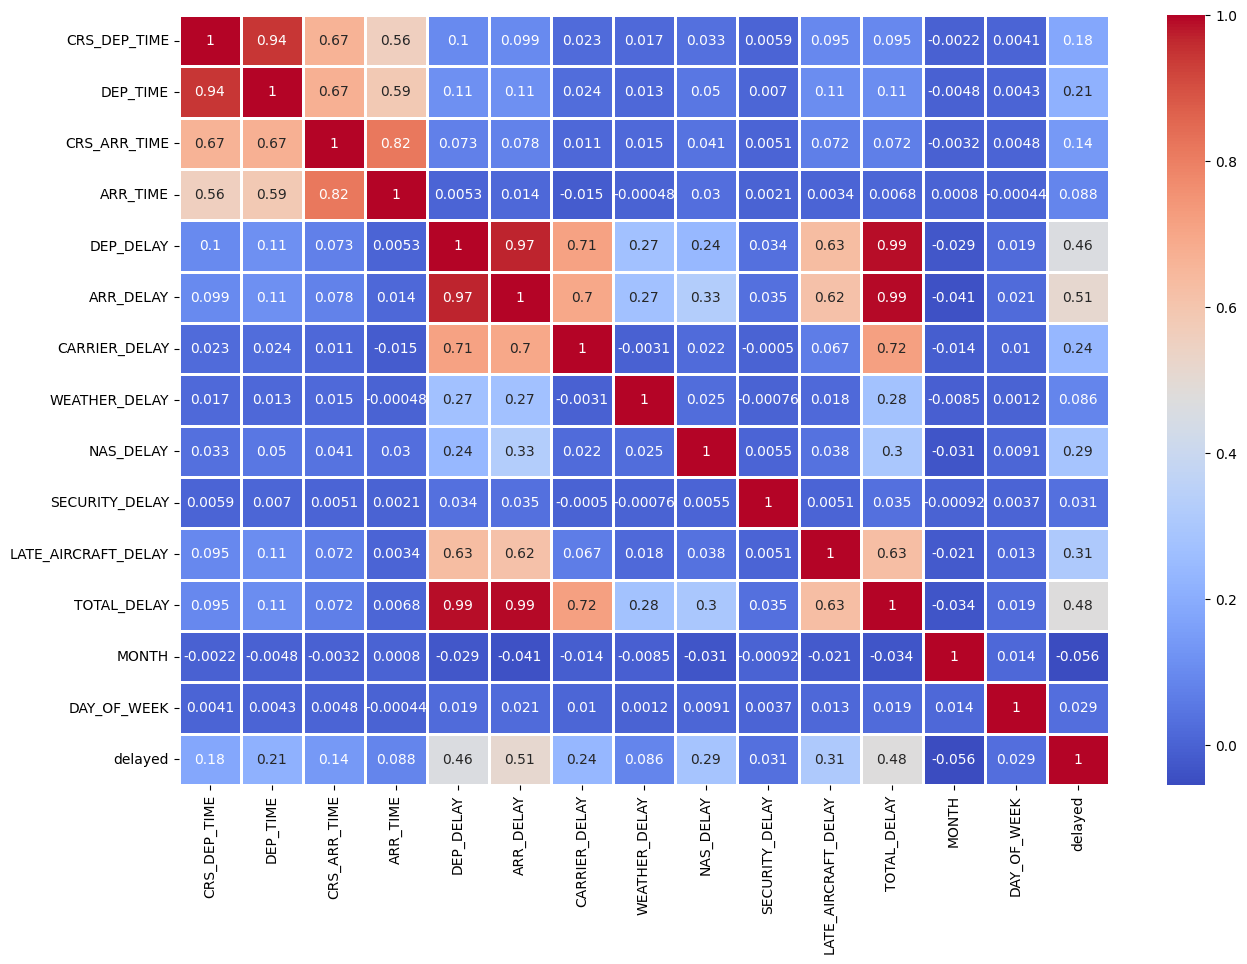

In [8]:
fig, ax = plt.subplots()
fig.set_size_inches(15, 10)
sns.heatmap(flight_clean_check.corr(),cmap='coolwarm',ax=ax,annot=True,linewidths=2)

In [9]:


features_to_drop = [
    'CRS_DEP_TIME',  # Correlated with DEP_TIME
    'DEP_TIME',  # Correlated with TOTAL_DELAY
    'CRS_ARR_TIME',  # Correlated with ARR_TIME
    'DEP_DELAY',  # Low correlation with the target variable 'delayed'
    'MONTH',  # Low correlation with the target variable 'delayed'
    'TOTAL_DELAY'
]

df_cleaned = flight_clean_check.drop(columns=features_to_drop)


<Axes: >

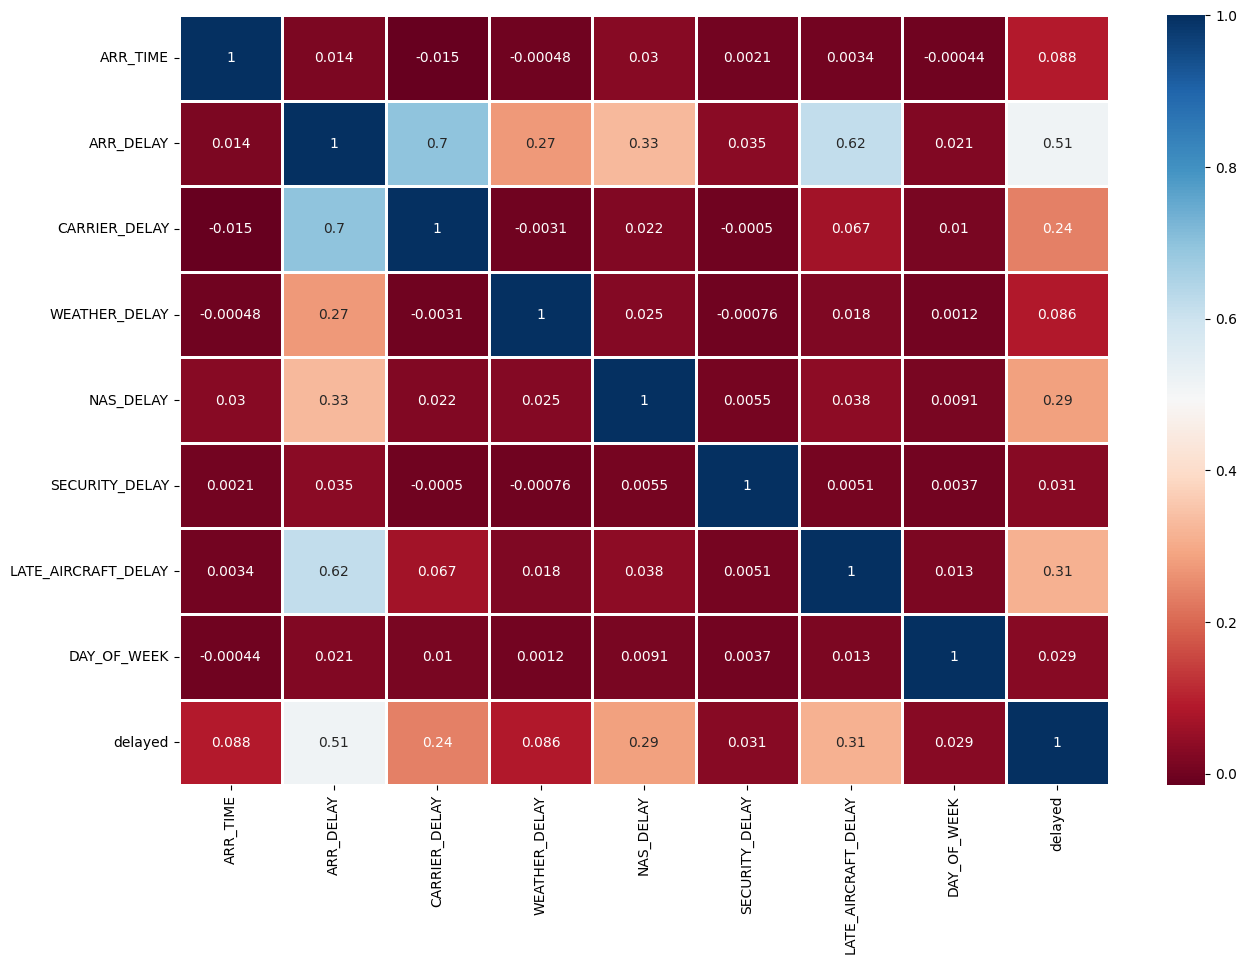

In [10]:
fig, ax = plt.subplots()
fig.set_size_inches(15, 10)
sns.heatmap(df_cleaned.corr(),cmap=plt.cm.RdBu,ax=ax,annot=True,linewidths=2)

In [11]:
features_to_drop_2 = [
    'CRS_DEP_TIME',  # Correlated with DEP_TIME
    'DEP_TIME',  # Correlated with TOTAL_DELAY
    'CRS_ARR_TIME',  # Correlated with ARR_TIME
    'DEP_DELAY',  # Low correlation with the target variable 'delayed'
    'MONTH'
]

In [12]:
X_train.drop(features_to_drop_2, axis=1, inplace=True)
X_test.drop(features_to_drop_2, axis=1, inplace=True)

In [52]:
X_train

,CARRIER_CODE,ORIGIN,DEST,ARR_TIME,ARR_DELAY,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,DAY_OF_WEEK
4747709,12.0,299.0,273.0,1211.0,-4.0,0.0,0.0,0.0,0.0,0.0,3
1407817,11.0,161.0,91.0,1244.0,-1.0,0.0,0.0,0.0,0.0,0.0,4
2023770,2.0,266.0,247.0,2006.0,-5.0,0.0,0.0,0.0,0.0,0.0,5
5032097,1.0,70.0,173.0,2218.0,-7.0,0.0,0.0,0.0,0.0,0.0,0
6710181,1.0,290.0,92.0,1110.0,-3.0,0.0,0.0,0.0,0.0,0.0,6
...,...,...,...,...,...,...,...,...,...,...,...
5460007,13.0,204.0,227.0,726.0,-19.0,0.0,0.0,0.0,0.0,0.0,4
3619416,4.0,216.0,21.0,1618.0,-19.0,0.0,0.0,0.0,0.0,0.0,4
3576700,1.0,299.0,70.0,540.0,-18.0,0.0,0.0,0.0,0.0,0.0,3
3597036,1.0,70.0,296.0,1942.0,19.0,19.0,0.0,0.0,0.0,0.0,3


In [25]:
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)


# Start here

In [ ]:
import pandas as pd

In [ ]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv")

In [27]:

num_cols = ['CARRIER_CODE','	ORIGIN','	DEST',	'ARR_TIME',	'ARR_DELAY'	]

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
import pandas as pd

cols = ['CARRIER_CODE', 'ORIGIN', 'DEST', 'ARR_TIME', 'ARR_DELAY']

X_train_original = X_train.copy()
X_test_original = X_test.copy()

# StandardScaler
std_scaler = StandardScaler()
X_train_stScaler = std_scaler.fit_transform(X_train_original[cols])
X_test_stScaler = std_scaler.transform(X_test_original[cols])

# MinMaxScaler
minmax_scaler = MinMaxScaler()
X_train_minmax = minmax_scaler.fit_transform(X_train_original[cols])
X_test_minmax = minmax_scaler.transform(X_test_original[cols])

# RobustScaler
robust_scaler = RobustScaler()
X_train_robust = robust_scaler.fit_transform(X_train_original[cols])
X_test_robust = robust_scaler.transform(X_test_original[cols])




